# 04 — Extensions: Louvain community detection + VADER sentiment

This notebook adds two analyses on top of the outputs already produced by `01_preprocessing.ipynb`, `02_network_analysis.ipynb`, and `03_topic_modelling.ipynb`. Both reproduce the figures and tables cited in section 4.4 and section 5.4 of the report.

**Inputs**
- `outputs/melbourne_liveability_youtube_user_video_edges_cleaned.csv`
- `outputs/melbourne_liveability_youtube_video_summary.csv`
- `outputs/melbourne_liveability_youtube_comments_with_topics.csv`

**Outputs**
- `outputs/figure_user_projection_communities.png`
- `outputs/table_community_profile.csv`
- `outputs/figure_sentiment_by_topic.png`
- `outputs/table_topic_sentiment.csv`

**Dependencies** (in addition to the existing notebook stack): `networkx ≥ 3.0` for `louvain_communities`, and `vaderSentiment` (`pip install vaderSentiment`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from networkx.algorithms.community import louvain_communities, modularity
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

OUTPUTS = Path('outputs')
assert OUTPUTS.exists(), 'Run from the project root so that outputs/ is visible.'

## Part A — Louvain community detection on the projection LCC

We rebuild the thresholded user–user projection using the same rules described in section 4.3 of the report (a user must have commented on ≥ 2 distinct videos, and an edge is drawn between two users iff they share ≥ 2 videos). We then run Louvain on the largest connected component, taking the best of seven random seeds to mitigate the algorithm's stochasticity. Modularity Q is reported as the standard quality score for the resulting partition.

In [2]:
edges = pd.read_csv(OUTPUTS / 'melbourne_liveability_youtube_user_video_edges_cleaned.csv')
by_user = edges.groupby('authorChannelId')['videoId'].apply(set)
eligible = by_user[by_user.apply(len) >= 2]

g = nx.Graph()
users = eligible.index.tolist()
user_videos = eligible.to_dict()
for i in range(len(users)):
    vs_i = user_videos[users[i]]
    for j in range(i + 1, len(users)):
        shared = len(vs_i & user_videos[users[j]])
        if shared >= 2:
            g.add_edge(users[i], users[j], weight=shared)

print(f'Projection: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges')

lcc_nodes = max(nx.connected_components(g), key=len)
lcc = g.subgraph(lcc_nodes).copy()
print(f'LCC: {lcc.number_of_nodes()} nodes, {lcc.number_of_edges()} edges')

Projection: 219 nodes, 970 edges
LCC: 206 nodes, 946 edges


In [3]:
best, best_q = None, -1.0
for seed in [0, 1, 7, 13, 42, 100, 2026]:
    comms = louvain_communities(lcc, seed=seed, weight='weight')
    q = modularity(lcc, comms, weight='weight')
    if q > best_q:
        best_q, best = q, comms

best_sorted = sorted(best, key=len, reverse=True)
node_to_comm = {n: ci for ci, comm in enumerate(best_sorted) for n in comm}

print(f'Modularity Q = {best_q:.3f}')
print(f'Number of communities: {len(best_sorted)}')
print(f'Community sizes (descending): {[len(c) for c in best_sorted]}')

Modularity Q = 0.687
Number of communities: 9
Community sizes (descending): [42, 33, 31, 27, 23, 16, 13, 12, 9]


### Community-by-theme profile

For each community we compute the share of its members' bipartite comment volume that falls in each video theme bucket. The dominant theme of each community and the videos that anchor it are saved to `table_community_profile.csv` and discussed in section 4.4 of the report.

In [4]:
videos = pd.read_csv(OUTPUTS / 'melbourne_liveability_youtube_video_summary.csv')
theme_lookup = dict(zip(videos['videoId'], videos['theme_bucket']))
title_lookup = dict(zip(videos['videoId'], videos['videoTitle']))

edges['community'] = edges['authorChannelId'].map(node_to_comm)
edges_c = edges.dropna(subset=['community']).copy()
edges_c['community'] = edges_c['community'].astype(int)
edges_c['theme'] = edges_c['videoId'].map(theme_lookup)

ct = pd.crosstab(edges_c['community'], edges_c['theme'],
                 normalize='index') * 100
top_theme = ct.idxmax(axis=1)

rows = []
for ci, comm in enumerate(best_sorted):
    sub_e = edges_c[edges_c['community'] == ci]
    vids = sub_e['videoId'].value_counts().head(2).index.tolist()
    rows.append({
        'community': ci,
        'size': len(comm),
        'top_theme': top_theme.get(ci, ''),
        'top_theme_pct': float(ct.loc[ci, top_theme[ci]]) if ci in ct.index else 0.0,
        'anchor_videos': ' · '.join(title_lookup.get(v, v)[:55] for v in vids),
    })

profile = pd.DataFrame(rows)
profile.to_csv(OUTPUTS / 'table_community_profile.csv', index=False)
profile.head(9)

,community,size,top_theme,top_theme_pct,anchor_videos
0,0,42,city_comparison,33.333333,🇦🇺 What Makes MELBOURNE Better Than SYDNEY In ...
1,1,33,transport_infrastructure,48.611111,What Is Livability? A Field Report from Melbou...
2,2,31,other,30.263158,Melbourne or Sydney? Which AUSTRALIAN City is ...
3,3,27,living_experience,63.076923,Should you live in Melbourne? | Pros and cons ...
4,4,23,transport_infrastructure,79.310345,SYDNEY TRAINS VS MELBOURNE TRAINS · Does Sydne...
5,5,16,cost_housing,33.333333,Should you live in Melbourne? Our HONEST thoug...
6,6,13,transport_infrastructure,76.666667,"The Comprehensive ""Metro"" Network of Melbourne..."
7,7,12,city_comparison,44.444444,Sydney and Melbourne Compared · LIVING IN SYDN...
8,8,9,other,42.857143,What Is Livability? A Field Report from Melbou...


### Figure 2 — LCC coloured by Louvain community

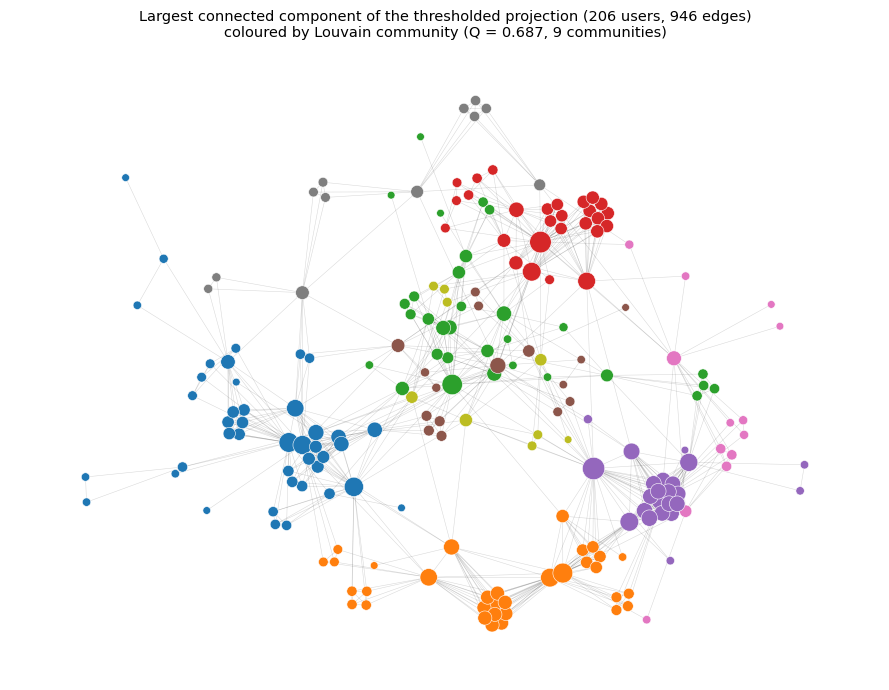

In [5]:
pos = nx.spring_layout(lcc, seed=42, k=0.5, iterations=120)
deg = dict(lcc.degree())

n_comms = len(best_sorted)
cmap = plt.colormaps['tab10'] if n_comms <= 10 else plt.colormaps['tab20']
colors = [cmap(node_to_comm[n] % cmap.N) for n in lcc.nodes()]
sizes = [25 + 6 * deg[n] for n in lcc.nodes()]

fig, ax = plt.subplots(figsize=(9, 7))
nx.draw_networkx_edges(lcc, pos, alpha=0.15, width=0.4, ax=ax)
nx.draw_networkx_nodes(lcc, pos, node_size=sizes, node_color=colors,
                       linewidths=0.4, edgecolors='white', ax=ax)
ax.set_axis_off()
ax.set_title(
    f'Largest connected component of the thresholded projection '
    f'({lcc.number_of_nodes()} users, {lcc.number_of_edges()} edges)\n'
    f'coloured by Louvain community (Q = {best_q:.3f}, {n_comms} communities)',
    fontsize=10.5)
fig.tight_layout()
fig.savefig(OUTPUTS / 'figure_user_projection_communities.png',
            dpi=180, bbox_inches='tight')
plt.show()

## Part B — VADER sentiment overlay per LDA topic

We score each of the 6,683 modelled comments with VADER (Hutto & Gilbert, 2014), aggregate the compound score by dominant LDA topic, and report both the mean compound and the share of comments classified positive / neutral / negative under the standard ±0.05 cutoffs. Results power Figure 6 and Table 6 in the report and inform the integrated discussion.

In [6]:
df = pd.read_csv(OUTPUTS / 'melbourne_liveability_youtube_comments_with_topics.csv')
print(f'Comments with topic assignments: {len(df):,}')

sia = SentimentIntensityAnalyzer()
df['compound'] = df['text'].apply(
    lambda t: sia.polarity_scores(t)['compound'] if isinstance(t, str) else np.nan
)
df['sent_class'] = pd.cut(
    df['compound'],
    bins=[-1.001, -0.05, 0.05, 1.001],
    labels=['negative', 'neutral', 'positive'],
).astype(str)

TOPIC_LABEL = {
    0: 'General liveability',
    1: 'City comparison',
    2: 'Transport',
    3: 'Cost of living',
    4: 'Identity debate',
    5: 'Creator replies',
}

grp = df.groupby('dominant_topic').agg(
    n=('compound', 'size'),
    mean_compound=('compound', 'mean'),
)
share = pd.crosstab(df['dominant_topic'], df['sent_class'], normalize='index') * 100
share.columns = [str(c) for c in share.columns]
grp = grp.join(share)
grp['label'] = grp.index.map(TOPIC_LABEL)
grp = grp[['label', 'n', 'mean_compound', 'positive', 'neutral', 'negative']]
grp.to_csv(OUTPUTS / 'table_topic_sentiment.csv')

print(f"\nCorpus mean compound: {df['compound'].mean():.3f}")
print(f"Corpus % positive: {(df['sent_class']=='positive').mean()*100:.1f}%")
grp.round(3)

Comments with topic assignments: 6,683



Corpus mean compound: 0.279
Corpus % positive: 58.9%


,label,n,mean_compound,positive,neutral,negative
dominant_topic,,,,,,
0,General liveability,842,0.376,64.252,25.297,10.451
1,City comparison,1556,0.345,65.231,18.638,16.131
2,Transport,1058,0.187,50.756,24.575,24.669
3,Cost of living,1099,0.104,44.586,26.206,29.208
4,Identity debate,1077,0.181,51.811,20.334,27.855
5,Creator replies,1051,0.477,75.452,13.701,10.847


### Figure 6 — Mean sentiment per topic

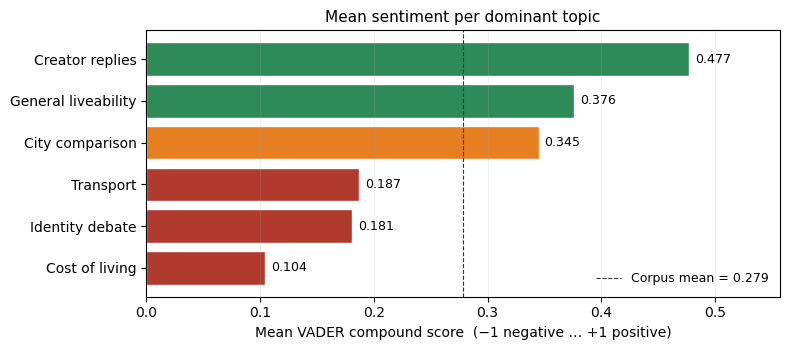

In [7]:
s = grp.sort_values('mean_compound')

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = ['#b03a2e' if v < 0.20 else '#e67e22' if v < 0.35 else '#2e8b57'
          for v in s['mean_compound']]
bars = ax.barh(s['label'], s['mean_compound'], color=colors, edgecolor='white')
ax.axvline(0, color='#777', linewidth=0.6)
corpus_mean = df['compound'].mean()
ax.axvline(corpus_mean, color='#333', linewidth=0.8, linestyle='--',
           label=f'Corpus mean = {corpus_mean:.3f}')
for bar, val in zip(bars, s['mean_compound']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean VADER compound score  (−1 negative … +1 positive)')
ax.set_title('Mean sentiment per dominant topic', fontsize=11)
ax.set_xlim(left=min(0, s['mean_compound'].min() - 0.05),
            right=s['mean_compound'].max() + 0.08)
ax.legend(loc='lower right', fontsize=9, frameon=False)
ax.grid(axis='x', alpha=0.25, linewidth=0.5)
fig.tight_layout()
fig.savefig(OUTPUTS / 'figure_sentiment_by_topic.png',
            dpi=180, bbox_inches='tight')
plt.show()

## Sanity-check summary

The next cell prints the numbers cited in the report's section 4.4 and section 5.4 so that they can be cross-checked against the prose without re-opening the CSVs.

In [8]:
print('Louvain on the projection LCC:')
print(f'  Q = {best_q:.3f}')
print(f'  Communities = {len(best_sorted)}')
print(f'  Sizes (top 5) = {[len(c) for c in best_sorted[:5]]}')
print()
print('VADER sentiment by topic (mean compound):')
for tid, row in grp.iterrows():
    print(f"  Topic {tid} {row['label']:>22}: mean = {row['mean_compound']:+.3f}, "
          f"%positive = {row['positive']:5.1f}%, %negative = {row['negative']:5.1f}%")

Louvain on the projection LCC:
  Q = 0.687
  Communities = 9
  Sizes (top 5) = [42, 33, 31, 27, 23]

VADER sentiment by topic (mean compound):
  Topic 0    General liveability: mean = +0.376, %positive =  64.3%, %negative =  10.5%
  Topic 1        City comparison: mean = +0.345, %positive =  65.2%, %negative =  16.1%
  Topic 2              Transport: mean = +0.187, %positive =  50.8%, %negative =  24.7%
  Topic 3         Cost of living: mean = +0.104, %positive =  44.6%, %negative =  29.2%
  Topic 4        Identity debate: mean = +0.181, %positive =  51.8%, %negative =  27.9%
  Topic 5        Creator replies: mean = +0.477, %positive =  75.5%, %negative =  10.8%
